# 🥗 Thai Calorie Calculator
### โปรแกรมคำนวณแคลอรี่อาหารไทย

**โปรเจคนี้ประกอบด้วย:**
- 📂 ฐานข้อมูลอาหารไทย 45+ รายการ (`data/thai_foods.csv`)
- 🔍 ค้นหาอาหารด้วยชื่อไทยหรืออังกฤษ
- 🧮 คำนวณแคลอรี่และสารอาหารรายมื้อ
- 📊 แสดงกราฟสัดส่วน Macronutrient
- 🏃 คำนวณ BMR / TDEE ส่วนตัว

---

## ⚙️ Setup — โหลด Library และโมดูล

In [10]:
import sys
import os

# เพิ่ม path ของโฟลเดอร์ src เพื่อ import โมดูล
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# ตั้งค่าฟอนต์สำหรับภาษาไทย
matplotlib.rcParams['font.family'] = 'Tahoma'

from calorie_calculator import (
    load_database,
    search_food,
    calculate_calories,
    summarize_meal,
    calculate_bmr,
    calculate_tdee,
    ACTIVITY_MULTIPLIER
)

# โหลดฐานข้อมูล
df = load_database(csv_path='../data/thai_foods.csv')
print(f"✅ โหลดสำเร็จ! มีอาหารทั้งหมด {len(df)} รายการ")

✅ โหลดสำเร็จ! มีอาหารทั้งหมด 44 รายการ


---
## 📋 ส่วนที่ 1 — ดูฐานข้อมูลอาหารทั้งหมด

In [11]:
# แสดงตัวอย่างฐานข้อมูล
print("📌 ตัวอย่างข้อมูล 10 รายการแรก:")
df.head(10)

📌 ตัวอย่างข้อมูล 10 รายการแรก:


,food_name_th,food_name_en,category,serving_unit,serving_size_g,calories,protein_g,carbs_g,fat_g,fiber_g
0,ข้าวสวย,Steamed Rice,ข้าวและแป้ง,ทัพพี,150,140,4.0,43.0,0.5,0.5
1,ข้าวเหนียว,Sticky Rice,ข้าวและแป้ง,ทัพพี,150,210,4.5,46.0,0.5,0.8
2,ข้าวผัดไข่,Egg Fried Rice,ข้าวและแป้ง,จาน,450,350,15.0,55.0,14.0,1.5
3,ข้าวมันไก่,Chicken Rice,ข้าวและแป้ง,จาน,300,480,28.0,58.0,12.0,1.0
4,ข้าวเนื้อแดง,Red beef Rice,ข้าวและแป้ง,จาน,280,510,25.0,60.0,16.0,1.2
5,ข้าวกะเพราไก่ไข่ดาว,Basil chicken Rice with Egg,ข้าวและแป้ง,จาน,300,550,28.0,52.0,22.0,2.0
6,ผัดไทย,Pad Thai,เส้น,จาน,250,400,20.0,55.0,12.0,2.5
7,ก๋วยเตี๋ยวเนื้อน้ำ,Beef Noodle Soup,เส้น,ชาม,400,380,22.0,50.0,8.0,2.0
8,บะหมี่เนื้อ,Beef Noodle,เส้น,ชาม,350,420,24.0,52.0,10.0,1.8
9,เส้นใหญ่ผัดซีอิ๊ว,Stir-Fried Wide Noodle,เส้น,จาน,300,460,18.0,65.0,12.0,2.0


In [12]:
# สรุปข้อมูลแต่ละหมวดหมู่
print("📂 หมวดหมู่อาหารทั้งหมด:")
category_count = df.groupby('category')['food_name_th'].count().reset_index()
category_count.columns = ['หมวดหมู่', 'จำนวนรายการ']
print(category_count.to_string(index=False))

📂 หมวดหมู่อาหารทั้งหมด:
     หมวดหมู่  จำนวนรายการ
      ขนมหวาน            5
  ข้าวและแป้ง            6
    ซุปและแกง            6
        ผลไม้            4
       ผัดผัก            3
    สลัดและยำ            3
  เครื่องดื่ม            5
   เนื้อสัตว์            3
         เส้น            5
ไข่และเต้าหู้            4


---
## 🔍 ส่วนที่ 2 — ค้นหาอาหาร

In [13]:
# ✏️ แก้ไขคำค้นหาได้เลย!
search_query = "fried"   # ลองพิมพ์: "ข้าว", "แกง", "fried", "ส้มตำ" ฯลฯ

results = search_food(search_query, df)

if results.empty:
    print(f"❌ ไม่พบอาหารที่ตรงกับ '{search_query}'")
else:
    print(f"✅ พบ {len(results)} รายการสำหรับ '{search_query}':")
    display(results[['food_name_th', 'food_name_en', 'category', 'serving_unit', 'calories']].rename(columns={
        'food_name_th': 'ชื่อไทย',
        'food_name_en': 'ชื่ออังกฤษ',
        'category': 'หมวดหมู่',
        'serving_unit': 'หน่วย',
        'calories': 'แคลอรี่/หน่วย'
    }))

✅ พบ 9 รายการสำหรับ 'fried':


,ชื่อไทย,ชื่ออังกฤษ,หมวดหมู่,หน่วย,แคลอรี่/หน่วย
0,ข้าวผัดไข่,Egg Fried Rice,ข้าวและแป้ง,จาน,350
1,เส้นใหญ่ผัดซีอิ๊ว,Stir-Fried Wide Noodle,เส้น,จาน,460
2,ไก่ทอด,Fried Chicken,เนื้อสัตว์,ชิ้น,220
3,หมูทอด,Fried Pork,เนื้อสัตว์,ชิ้น,280
4,ปลาทอด,Fried Fish,เนื้อสัตว์,ชิ้น,220
5,ไข่ดาว,Fried Egg,ไข่และเต้าหู้,ฟอง,200
6,เต้าหู้ทอด,Fried Tofu,ไข่และเต้าหู้,ชิ้น,180
7,ผัดคะน้าเนื้อ,Stir-fried Kale with Beef,ผัดผัก,จาน,280
8,ผักบุ้งไฟแดง,Stir-fried Morning Glory,ผัดผัก,จาน,150


---
## 🧮 ส่วนที่ 3 — คำนวณแคลอรี่รายมื้อ

In [14]:
# ─────────────────────────────────────────────────────────────
# ✏️ แก้ไขมื้ออาหารได้ที่นี่!
# รูปแบบ: ("ชื่ออาหาร", จำนวน)
# ─────────────────────────────────────────────────────────────
my_meal = [
    ("ข้าว",        1.0),
    ("ไก่ทอด",         2.0),
    ("ต้มยำกุ้ง",        1.0),
    ("น้ำเปล่า",       1.0),
]
# ─────────────────────────────────────────────────────────────

meal_items = []
not_found  = []

for food_name, qty in my_meal:
    results = search_food(food_name, df)
    if results.empty:
        not_found.append(food_name)
        print(f"⚠️  ไม่พบ: '{food_name}' — ข้ามรายการนี้")
    else:
        food_row = results.iloc[0]  # ใช้รายการแรกที่ตรงกัน
        info = calculate_calories(food_row, qty)
        meal_items.append(info)

print()
print("┌─────────────────────────────────────────────────────────┐")
print("│                  🍽️  รายการอาหารมื้อนี้                     │")
print("└─────────────────────────────────────────────────────────┘")
for item in meal_items:
    print(f"  {item['ชื่ออาหาร']:<20} ({item['จำนวน']:<12})  →  {item['แคลอรี่']:>6} kcal")

print()
summary = summarize_meal(meal_items)
if summary:
    print("┌─────────────────────────────────────────────────────────┐")
    print("│                    📊 สรุปมื้ออาหาร                     │")
    print("└─────────────────────────────────────────────────────────┘")
    print(f"  🔥 แคลอรี่รวม Total Calories     : {summary['แคลอรี่รวม']:>7} kcal")
    print(f"  🥩 โปรตีนรวม Total Protein     : {summary['โปรตีนรวม (g)']:>7} g")
    print(f"  🍚 คาร์บรวม Total Carbs      : {summary['คาร์บรวม (g)']:>7} g")
    print(f"  🧈 ไขมันรวม Total Fat      : {summary['ไขมันรวม (g)']:>7} g")
    print(f"  🌿 ใยอาหารรวม Total Fiber    : {summary['ใยอาหารรวม (g)']:>7} g")


┌─────────────────────────────────────────────────────────┐
│                  🍽️  รายการอาหารมื้อนี้                     │
└─────────────────────────────────────────────────────────┘
  ข้าวสวย              (1.0 ทัพพี   )  →   140.0 kcal
  ไก่ทอด               (2.0 ชิ้น    )  →   440.0 kcal
  ต้มยำกุ้ง            (1.0 ชาม     )  →   180.0 kcal
  น้ำเปล่า             (1.0 แก้ว    )  →     0.0 kcal

┌─────────────────────────────────────────────────────────┐
│                    📊 สรุปมื้ออาหาร                     │
└─────────────────────────────────────────────────────────┘
  🔥 แคลอรี่รวม Total Calories     :   760.0 kcal
  🥩 โปรตีนรวม Total Protein     :    68.0 g
  🍚 คาร์บรวม Total Carbs      :    67.0 g
  🧈 ไขมันรวม Total Fat      :    36.5 g
  🌿 ใยอาหารรวม Total Fiber    :     3.5 g


---
## 📊 ส่วนที่ 4 — กราฟ Macronutrient Breakdown

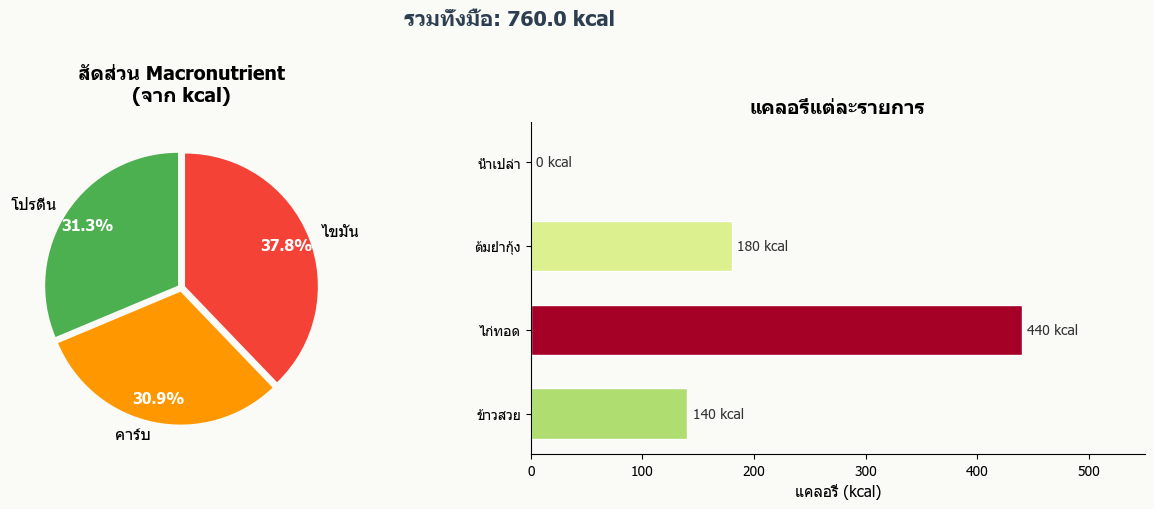

💾 บันทึกกราฟไว้ที่ data/meal_chart.png


In [15]:
if summary and meal_items:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.patch.set_facecolor('#FAFAF7')

    # ── กราฟซ้าย: Macronutrient Pie Chart ─────────────────────
    macro_labels  = ['โปรตีน', 'คาร์บ', 'ไขมัน']
    macro_values  = [
        summary['โปรตีนรวม (g)']  * 4,   # 4 kcal/g
        summary['คาร์บรวม (g)']   * 4,   # 4 kcal/g
        summary['ไขมันรวม (g)']   * 9,   # 9 kcal/g
    ]
    colors = ['#4CAF50', '#FF9800', '#F44336']
    explode = (0.03, 0.03, 0.03)

    wedges, texts, autotexts = axes[0].pie(
        macro_values, labels=macro_labels, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=explode,
        textprops={'fontsize': 12}, pctdistance=0.82
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight('bold')
        at.set_color('white')
    axes[0].set_title('สัดส่วน Macronutrient\n(จาก kcal)', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_facecolor('#FAFAF7')

    # ── กราฟขวา: Bar Chart รายอาหาร ───────────────────────────
    food_names = [item['ชื่ออาหาร'] for item in meal_items]
    cal_values = [item['แคลอรี่']   for item in meal_items]

    bar_colors = plt.cm.RdYlGn_r(
        [v / max(cal_values) for v in cal_values]
    )
    bars = axes[1].barh(food_names, cal_values, color=bar_colors, edgecolor='white', height=0.6)

    for bar, val in zip(bars, cal_values):
        axes[1].text(
            bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f} kcal', va='center', fontsize=10, color='#333'
        )

    axes[1].set_xlabel('แคลอรี่ (kcal)', fontsize=11)
    axes[1].set_title('แคลอรี่แต่ละรายการ', fontsize=14, fontweight='bold')
    axes[1].set_facecolor('#FAFAF7')
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].set_xlim(0, max(cal_values) * 1.25)

    plt.suptitle(
        f'รวมทั้งมื้อ: {summary["แคลอรี่รวม"]} kcal',
        fontsize=15, fontweight='bold', y=1.01, color='#2C3E50'
    )
    plt.tight_layout()
    plt.savefig('../data/meal_chart.png', dpi=150, bbox_inches='tight', facecolor='#FAFAF7')
    plt.show()
    print("💾 บันทึกกราฟไว้ที่ data/meal_chart.png")
else:
    print("⚠️ ไม่มีข้อมูลมื้ออาหาร กรุณากลับไปทำส่วนที่ 3 ก่อน")

---
## 🏃 ส่วนที่ 5 — คำนวณ BMR / TDEE ส่วนตัว

In [16]:
# ─────────────────────────────────────────────
# ✏️ แก้ไขข้อมูลส่วนตัวได้ที่นี่!
# ─────────────────────────────────────────────
MY_WEIGHT    = 70      # กิโลกรัม
MY_HEIGHT    = 168     # เซนติเมตร
MY_AGE       = 36      # ปี
MY_GENDER    = "male"  # "male" หรือ "female"
MY_ACTIVITY  = "นั่งทำงาน (sedentary)"  # เลือกจากตัวเลือกด้านล่าง
# ─────────────────────────────────────────────
# ตัวเลือก activity level:
# "นั่งทำงาน (sedentary)"
# "ออกกำลังเบา (light)"
# "ออกกำลังปานกลาง (moderate)"
# "ออกกำลังหนัก (active)"
# "ออกกำลังหนักมาก (very active)"
# ─────────────────────────────────────────────

bmr  = calculate_bmr(MY_WEIGHT, MY_HEIGHT, MY_AGE, MY_GENDER)
tdee = calculate_tdee(bmr, MY_ACTIVITY)

print("┌───────────────────────────────────────────┐")
print("│         🧬 ผลการคำนวณพลังงานต่อวัน         │")
print("└───────────────────────────────────────────┘")
print(f"  น้ำหนัก  : {MY_WEIGHT} kg")
print(f"  ส่วนสูง  : {MY_HEIGHT} cm")
print(f"  อายุ     : {MY_AGE} ปี")
print(f"  เพศ      : {'ชาย' if MY_GENDER == 'male' else 'หญิง'}")
print(f"  กิจกรรม  : {MY_ACTIVITY}")
print()
print(f"  🔥 BMR  (พลังงานขณะพัก Energy at rest)  : {bmr:,.0f} kcal/วัน")
print(f"  ⚡ TDEE (พลังงานทั้งหมด Total energy) : {tdee:,.0f} kcal/วัน")
print()

# เปรียบเทียบกับมื้ออาหารของเรา
if summary:
    meal_cal = summary['แคลอรี่รวม']
    pct = meal_cal / tdee * 100
    print(f"  🍽️  มื้อนี้คิดเป็น {pct:.1f}% ของพลังงานที่ควรได้รับต่อวัน")
    remaining = tdee - meal_cal
    if remaining > 0:
        print(f"  📉 เหลืออีก {remaining:,.0f} kcal สำหรับวันนี้")
    else:
        print(f"  📈 เกินโควต้า {abs(remaining):,.0f} kcal แล้ว!")

┌───────────────────────────────────────────┐
│         🧬 ผลการคำนวณพลังงานต่อวัน         │
└───────────────────────────────────────────┘
  น้ำหนัก  : 70 kg
  ส่วนสูง  : 168 cm
  อายุ     : 36 ปี
  เพศ      : ชาย
  กิจกรรม  : นั่งทำงาน (sedentary)

  🔥 BMR  (พลังงานขณะพัก Energy at rest)  : 1,575 kcal/วัน
  ⚡ TDEE (พลังงานทั้งหมด Total energy) : 1,890 kcal/วัน

  🍽️  มื้อนี้คิดเป็น 40.2% ของพลังงานที่ควรได้รับต่อวัน
  📉 เหลืออีก 1,130 kcal สำหรับวันนี้


---
## 📈 ส่วนที่ 6 — เปรียบเทียบแคลอรี่หลายๆ เมนู

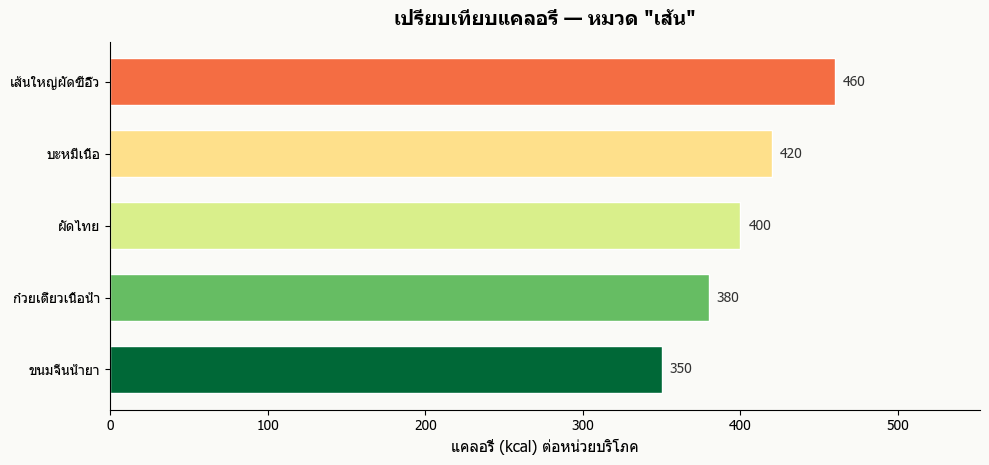

In [17]:
# เปรียบเทียบอาหารในหมวดหมู่เดียวกัน
# ─────────────────────────────────────────────
compare_category = "เส้น"  # ✏️ แก้ได้!
# ─────────────────────────────────────────────

cat_df = df[df['category'] == compare_category].sort_values('calories')

if cat_df.empty:
    print(f"ไม่พบหมวดหมู่: {compare_category}")
else:
    fig, ax = plt.subplots(figsize=(10, len(cat_df) * 0.65 + 1.5))
    fig.patch.set_facecolor('#FAFAF7')

    colors = plt.cm.RdYlGn_r(
        [i / len(cat_df) for i in range(len(cat_df))]
    )
    bars = ax.barh(cat_df['food_name_th'], cat_df['calories'],
                   color=colors, edgecolor='white', height=0.65)

    for bar, val in zip(bars, cat_df['calories']):
        ax.text(
            bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=10, color='#333'
        )

    ax.set_xlabel('แคลอรี่ (kcal) ต่อหน่วยบริโภค', fontsize=11)
    ax.set_title(f'เปรียบเทียบแคลอรี่ — หมวด "{compare_category}"',
                 fontsize=14, fontweight='bold', pad=12)
    ax.set_facecolor('#FAFAF7')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, cat_df['calories'].max() * 1.2)

    plt.tight_layout()
    plt.show()

---
*Thai Calorie Calculator — โปรเจคนี้สร้างด้วย Python + pandas + matplotlib*